In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
def LCG_A(N, seed=1):
    a = 5
    b = 1
    m = 16
    rand_nums = np.empty(N)
    for i in range(N):
        if i == 0:
            rand_nums[i] = (a*seed + b) % m
        else:
            rand_nums[i] = (a*rand_nums[i-1] + b) % m
    return rand_nums

In [3]:
def LCG_B(N, seed=1):
    a = 13
    b = 7
    m = 64
    rand_nums = np.empty(N)
    for i in range(N):
        if i == 0:
            rand_nums[i] = (a*seed + b) % m
        else:
            rand_nums[i] = (a*rand_nums[i-1] + b) % m
    return rand_nums

In [4]:
A_normal = LCG_A(16) / 16
# print(A_normal)
B_normal = LCG_B(64) / 64
# print(B_normal)

I_a = 1/16 * np.sum(np.sqrt(1- A_normal**2))
print(I_a)
I_b = 1/64 * np.sum(np.sqrt(1- B_normal**2))
print(I_b)

0.8120632594569352
0.792636728194921


3. Generator B is closer to the true value (~0.7854) because there are more samples.

4. If the period of the rng much less than the number of samples we want to generate, we will start to see repetition in the generated numbers. The numbers are no longer random since they have a clear and predictable pattern.

5. A short period could lead to preferences for certain values at a high number of samples and could throw off monte carlo simulations

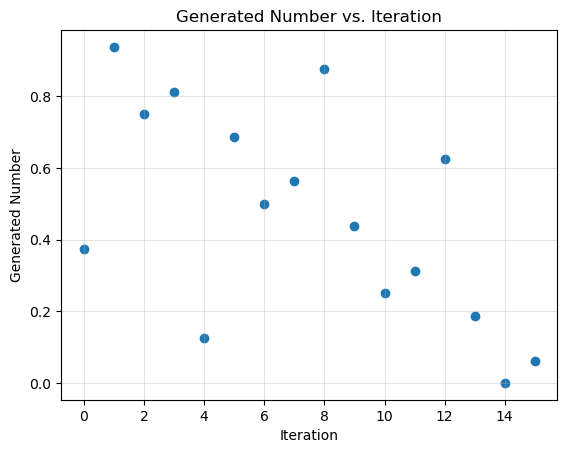

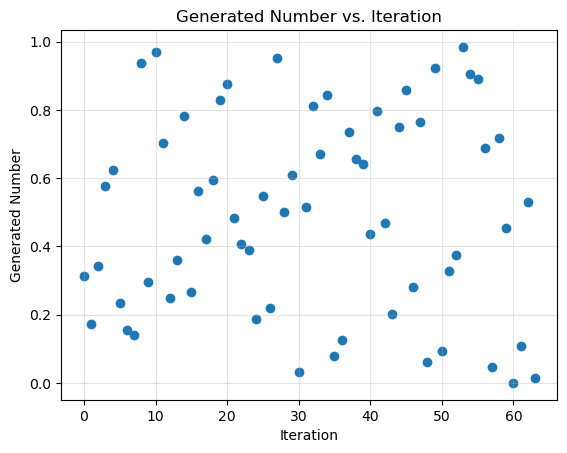

In [5]:
xs_A = np.arange(16)
xs_B = np.arange(64)

plt.scatter(xs_A, A_normal)
plt.title("Generated Number vs. Iteration")
plt.ylabel("Generated Number")
plt.xlabel("Iteration")
plt.grid(visible=True, which="both", alpha=0.35)
plt.show()

plt.scatter(xs_B, B_normal)
plt.title("Generated Number vs. Iteration")
plt.ylabel("Generated Number")
plt.xlabel("Iteration")
plt.grid(visible=True, which="both", alpha=0.35)
plt.show()

5. The outputs look pretty uniformly distributed. Visually, they seem to have serial correlation.

In [15]:
def LCG_C(N, seed=1):
    a = 5
    b = 1
    m = 2**10
    rand_nums = np.empty(N)
    for i in range(N):
        if i == 0:
            rand_nums[i] = (a*seed + b) % m
        else:
            rand_nums[i] = (a*rand_nums[i-1] + b) % m
    return rand_nums

[ 11.  56. 281. 382. 887. 340. 677. 314. 547. 688. 369. 822.  15.  76.
 381. 882. 315. 552. 713. 494. 423.  68. 341. 682. 339. 672. 289. 422.
  63. 316. 557. 738.]


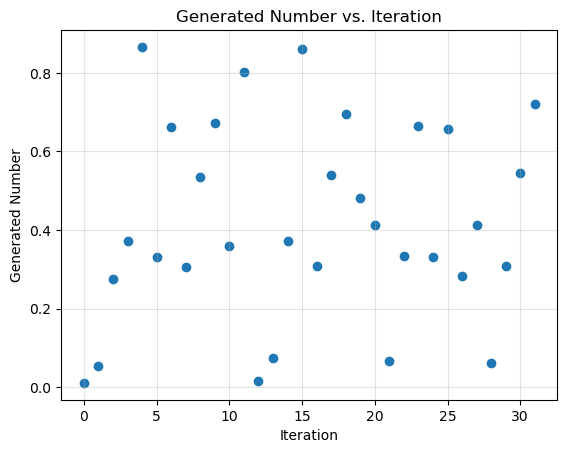

In [19]:
print(LCG_C(32, seed=2))
plt.scatter(np.arange(32), LCG_C(32, seed=2)/2**10)
plt.title("Generated Number vs. Iteration")
plt.ylabel("Generated Number")
plt.xlabel("Iteration")
plt.grid(visible=True, which="both", alpha=0.35)
plt.show()